<a href="https://colab.research.google.com/github/Harshkotkar/jupyter/blob/main/nreuralnetwork_classification_problem_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from sklearn.datasets import make_circles



a classification is where we try to classify one thing or another
AS THERE ARE 3 TYPE OF THE Classification

*   binary classification
*   multiclass classification
*   multilable classification


In [50]:
#making 1000 examples
n_samples=1000
X,Y=make_circles(n_samples=n_samples,
                 noise=0.03,
                 random_state=42)

In [51]:
X


array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]])

In [52]:
Y[:10]

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0])

In [53]:
# structed format
circles=pd.DataFrame({"X0":X[:,0],"X1":X[:,1],"lable":Y})

In [54]:
circles.head()

,X0,X1,lable
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


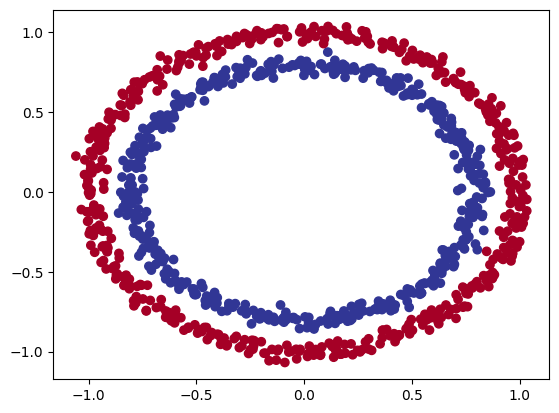

In [55]:
plt.scatter(X[:,0],X[:,1],c=Y,cmap=plt.cm.RdYlBu);

In [56]:
from sklearn.model_selection import train_test_split
x=circles[["X0","X1"]]
y=circles["lable"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [57]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras import Sequential,optimizers
from tensorflow.keras import layers,losses,metrics

In [61]:
model=models.Sequential([
    layers.Dense(200,activation="relu",input_shape=(2,)),
    layers.Dense(100,activation="relu"),
    layers.Dense(64,activation="relu"),
    layers.Dense(1,activation="sigmoid")
])


In [62]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop=EarlyStopping(monitor="val_loss",
                         patience=20,
                         restore_best_weights=True)

In [63]:
from tensorflow.keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.001),
              loss="binary_crossentropy",
              metrics=["accuracy"])

In [64]:
history=model.fit(x_train,y_train,
          epochs=100,
          batch_size=64,
          validation_split=0.1,
          callbacks=[early_stop])

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.4852 - loss: 0.6915 - val_accuracy: 0.4875 - val_loss: 0.6931
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5037 - loss: 0.6845 - val_accuracy: 0.4875 - val_loss: 0.6909
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4923 - loss: 0.6819 - val_accuracy: 0.5000 - val_loss: 0.6856
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5985 - loss: 0.6726 - val_accuracy: 0.5625 - val_loss: 0.6798
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6551 - loss: 0.6650 - val_accuracy: 0.5375 - val_loss: 0.6693
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6107 - loss: 0.6496 - val_accuracy: 0.5250 - val_loss: 0.6441
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5604 - loss: 0.6174 - val_accuracy: 0.8750 - val_loss: 0.6118
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8478 - loss: 0.5887 - val_accuracy: 0.6375 -

In [65]:
test_loss,test_acc=model.evaluate(x_test,y_test)
print(test_loss)
print(test_acc)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0026 
0.003168804571032524
1.0


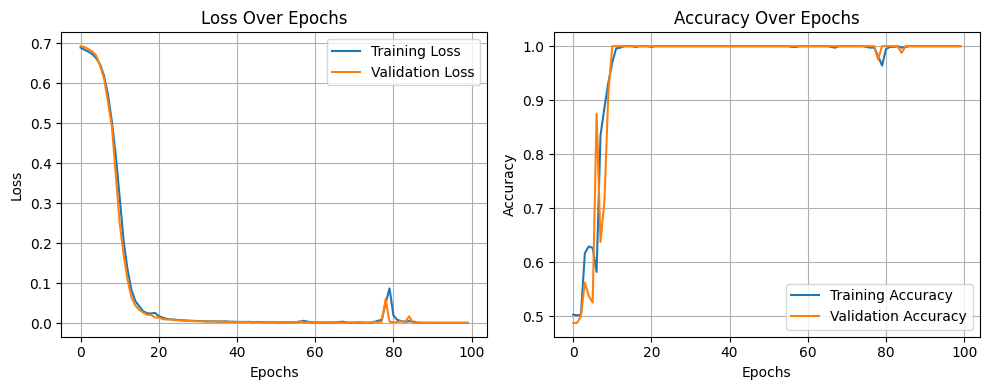

In [66]:
import matplotlib.pyplot as plt

# Assuming this comes from your model training:
# history = model.fit(...)

# Loss Plot
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


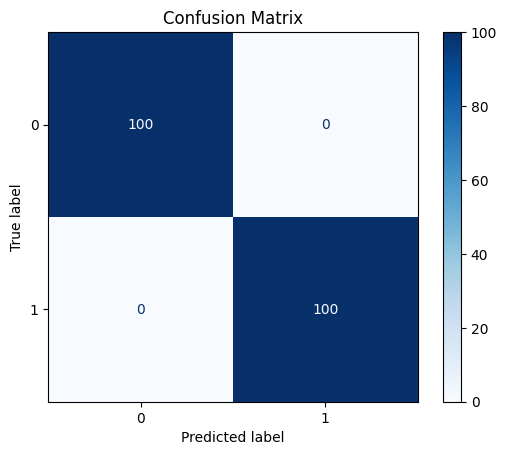

In [67]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(x_test)
y_pred_classes = (y_pred > 0.5).astype("int32")


cm = confusion_matrix(y_test, y_pred_classes)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()
